In [1]:
import pandas as pd
import numpy as np
from coffea import util
import itertools
import os, sys
import matplotlib.pyplot as plt
import mplhep as hep
import uproot
import hist
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle
import warnings
hep.style.use("CMS")

sys.path.append('../python/')
from functions import loadCoffeaFile, getLabelMap, getCoffeaFilenames, plotBackgroundEstimate, getHist


In [2]:
def getHist(hname, ds, bkgest, year, sum_axes=[], integrate_axes={}, masspoint=''): # Copied and modified from `closureTest.ipynb`
    
    ######################################################################################
    # hname = histogram name (example: 'ttbarmass')                                      #
    # ds = dataset name (example: 'JetHT')                                               #
    # bkgest = boolean, True if bkg estimate applied                                     #
    # year = '2016APV' or '2016' or '2017' or '2018'                                     #
    # sum_axes = names of axes to sum over for scikit-hep/hist histogram                 #
    # integrate_axes = range to integrate over axis (example: {'anacat': [0,1,2,3,4,5]}) #
    ######################################################################################    

    
    # load histograms and get scale factors
    coffeaFiles = getCoffeaFilenames(False, useOldHTcut, False)
    
    cfiles = []
    bkgest_str = np.where([bkgest], 'weighted', 'unweighted')[0]
    # print(coffeaFiles[ds][bkgest_str][year])
    
     
    for key, file in coffeaFiles[ds][bkgest_str][year].items():
        if masspoint != '':
            # print('Grabbing signal...')
            if masspoint in key:
                loaded_file = LoadedFiles[ds][bkgest_str][year][masspoint]
                sum_axes_dict = {ax:sum for ax in sum_axes}
                histo = loaded_file[hname][integrate_axes][sum_axes_dict]
                histo = histo * (lumi[year] * 1.0 / loaded_file['cutflow']['sumw'])
                return histo

        loaded_file = LoadedFiles[ds][bkgest_str][year][key]
        cfiles.append(loaded_file)
        
    # sum or integrate axes for all hists from dataset eras or pt bins
    sum_axes_dict = {ax:sum for ax in sum_axes}
    
    hists = []
    
    for cfile in cfiles:
        hists.append(cfile[hname][integrate_axes][sum_axes_dict])   
    
#     # sum all hists from dataset eras or pt bins
    
    histo = hists[0]
    if len(hists) > 1:
        for i in range(len(hists) - 1): 
            histo = histo + hists[i+1]
            
    return histo

In [3]:
useOldHTcut = False

lumi = {
    "2016APV": 19800.,
    "2016": 16120., #35920 - 19800
    "2016all": 35920,
    "2017": 41530.,
    "2018": 59800., #59740./10., #Blinding
    "Full": 46053. # 137190. Blinded
}

systematics = [
        'jes',
        'jer',
        'pileup',
        'pdf',
        'q2',
        'btag',
        'toptagsf',
        'toptagxs',
        'lumi',
        'prefiring'
    ]

In [4]:
# load histograms and get scale factors
coffeaFiles = getCoffeaFilenames(False, useOldHTcut, True)

LoadedFiles = {
    'RSGluon':{
        'unweighted':{
            '2016APV': {'1000':None, '1500':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None},
            '2016': {'1000':None, '1500':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None},
            '2017': {'1000':None, '1500':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None},
            '2018': {'1000':None, '1500':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None}
        }
    },
    'ZPrime1':{
        'unweighted':{
            '2016APV': {'1000':None, '1200':None, '1400':None, '1600':None, '1800':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None},
            '2016': {'1000':None, '1200':None, '1400':None, '1600':None, '1800':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None},
            '2017': {'1000':None, '1200':None, '1400':None, '1600':None, '1800':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None},
            '2018': {'1000':None, '1200':None, '1400':None, '1600':None, '1800':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None}
        }
    },
    'ZPrime10':{
        'unweighted':{
            '2016APV': {'1000':None, '1200':None, '1400':None, '1600':None, '1800':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None},
            '2016': {'1000':None, '1200':None, '1400':None, '1600':None, '1800':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None},
            '2017': {'1000':None, '1200':None, '1400':None, '1600':None, '1800':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None},
            '2018': {'1000':None, '1200':None, '1400':None, '1600':None, '1800':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None}
        }
    },
    'ZPrime30':{
        'unweighted':{
            '2016APV': {'1000':None, '1200':None, '1400':None, '1600':None, '1800':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None},
            '2016': {'1000':None, '1200':None, '1400':None, '1600':None, '1800':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None},
            '2017': {'1000':None, '1200':None, '1400':None, '1600':None, '1800':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None},
            '2018': {'1000':None, '1200':None, '1400':None, '1600':None, '1800':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None}
        }
    },
    'ZPrimeDM':{
        'unweighted':{
            '2016APV': {'1000':None, '1500':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None},
            '2016': {'1000':None, '1500':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None},
            '2017': {'1000':None, '1500':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None},
            '2018': {'1000':None, '1500':None, '2000':None, '2500':None, '3000':None, '3500':None, '4000':None, '4500':None, '5000':None}
        }
    }
}

In [37]:
bkgest_str = 'unweighted'
plotHist = 'ZPrime30'
for year in ['2016APV', '2016', '2017', '2018']:
    for ds in [plotHist]: #, 'ZPrime1', 'ZPrime10', 'ZPrime30', 'ZPrimeDM']:
        for key, file in coffeaFiles[ds][bkgest_str][year].items():
            LoadedFiles[ds][bkgest_str][year][key] = (util.load(file))
            print(file + ' loaded') # for masspoint ' + key)

/srv/outputs/ZPrime1000_30_2016APV.coffea loaded
/srv/outputs/ZPrime1200_30_2016APV.coffea loaded
/srv/outputs/ZPrime1400_30_2016APV.coffea loaded
/srv/outputs/ZPrime1600_30_2016APV.coffea loaded
/srv/outputs/ZPrime1800_30_2016APV.coffea loaded
/srv/outputs/ZPrime2000_30_2016APV.coffea loaded
/srv/outputs/ZPrime2500_30_2016APV.coffea loaded
/srv/outputs/ZPrime3000_30_2016APV.coffea loaded
/srv/outputs/ZPrime3500_30_2016APV.coffea loaded
/srv/outputs/ZPrime4000_30_2016APV.coffea loaded
/srv/outputs/ZPrime4500_30_2016APV.coffea loaded
/srv/outputs/ZPrime5000_30_2016APV.coffea loaded
/srv/outputs/ZPrime1000_30_2016.coffea loaded
/srv/outputs/ZPrime1200_30_2016.coffea loaded
/srv/outputs/ZPrime1400_30_2016.coffea loaded
/srv/outputs/ZPrime1600_30_2016.coffea loaded
/srv/outputs/ZPrime1800_30_2016.coffea loaded
/srv/outputs/ZPrime2000_30_2016.coffea loaded
/srv/outputs/ZPrime2500_30_2016.coffea loaded
/srv/outputs/ZPrime3000_30_2016.coffea loaded
/srv/outputs/ZPrime3500_30_2016.coffea loade

In [38]:
LoadedFiles[plotHist]['unweighted']['2018']['1000']['cutflow']

defaultdict_accumulator(int,
                        {'all events': 500000,
                         'sumw': 431118.0,
                         'Passed HT Cut': 7668,
                         'Passed Loose Jet ID': 7668,
                         'Passed pT,y Cut': 7668,
                         '>= 2 AK8 Jets': 6526,
                         '>= one TTbar': 6526,
                         'Passed dPhi Cut': 6351,
                         'Good Subjets': 6300,
                         'at0bcen': 293,
                         'at0bfwd': 99,
                         'at1bcen': 690,
                         'at1bfwd': 157,
                         'at2bcen': 353,
                         'at2bfwd': 84,
                         'pret0bcen': 352,
                         'pret0bfwd': 114,
                         'pret1bcen': 916,
                         'pret1bfwd': 229,
                         'pret2bcen': 514,
                         'pret2bfwd': 104,
                         '2t0bcen':

In [39]:
LoadedFiles[plotHist]['unweighted']['2018']['1000']['weights']

defaultdict_accumulator(float,
                        {'nominal total': 110382.69668710668,
                         'q2Up total': 117883.04071265635,
                         'btagDown total': 112697.69260104783,
                         'pileupUp total': 110995.06785853219,
                         'lumiDown total': 107623.12926992904,
                         'btagUp total': 107487.85004491486,
                         'pdfUp total': 112162.04811220273,
                         'pdfDown total': 113941.39953729877,
                         'q2Down total': 103662.08101777469,
                         'lumiUp total': 113142.26410428436,
                         'pileupDown total': 109736.18569411444,
                         'jesUp total': 118801.19806649201,
                         'jesDown total': 103293.56955041658,
                         'jerUp total': 111057.1980975006,
                         'jerDown total': 109829.69685054717})

In [40]:
LoadedFiles[plotHist]['unweighted']['2018']['1200']['cutflow']

defaultdict_accumulator(int,
                        {'all events': 494000,
                         'sumw': 426601.0,
                         'Passed HT Cut': 19497,
                         'Passed Loose Jet ID': 19497,
                         'Passed pT,y Cut': 19497,
                         '>= 2 AK8 Jets': 17552,
                         '>= one TTbar': 17552,
                         'Passed dPhi Cut': 17281,
                         'Good Subjets': 17160,
                         'at0bcen': 778,
                         'at0bfwd': 205,
                         'at1bcen': 1825,
                         'at1bfwd': 450,
                         'at2bcen': 1046,
                         'at2bfwd': 224,
                         'pret0bcen': 1041,
                         'pret0bfwd': 257,
                         'pret1bcen': 2606,
                         'pret1bfwd': 572,
                         'pret2bcen': 1673,
                         'pret2bfwd': 330,
                     

In [41]:
LoadedFiles[plotHist]['unweighted']['2018']['1200']['weights']

defaultdict_accumulator(float,
                        {'nominal total': 301778.4431821123,
                         'pdfUp total': 306521.2972847541,
                         'lumiDown total': 294233.98210255953,
                         'pdfDown total': 311264.15138739586,
                         'q2Up total': 323227.07158447837,
                         'q2Down total': 282642.2805924222,
                         'lumiUp total': 309322.9042616651,
                         'btagUp total': 295715.4733417179,
                         'pileupUp total': 305295.69337835565,
                         'pileupDown total': 298417.58145601745,
                         'btagDown total': 306344.11444898084,
                         'jesUp total': 323154.8780460118,
                         'jesDown total': 281880.05496775894,
                         'jerUp total': 303189.8492367046,
                         'jerDown total': 300455.8955985496})

In [42]:
# analysis categories #
label_dict = LoadedFiles[plotHist]['unweighted']['2016']['1000']['analysisCategories']
label_to_int_dict = {label: i for i, label in label_dict.items()}
print(label_dict)

# LoadedFiles[plotHist]['unweighted']['2016']['1000']['ttbarmass'][{'anacat':signal_cats, 'systematic':'nominal'}]

{0: 'at0bcen', 1: 'at0bfwd', 2: 'at1bcen', 3: 'at1bfwd', 4: 'at2bcen', 5: 'at2bfwd', 6: 'pret0bcen', 7: 'pret0bfwd', 8: 'pret1bcen', 9: 'pret1bfwd', 10: 'pret2bcen', 11: 'pret2bfwd', 12: '2t0bcen', 13: '2t0bfwd', 14: '2t1bcen', 15: '2t1bfwd', 16: '2t2bcen', 17: '2t2bfwd'}


In [43]:
#signal_cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
category = '0bcen'
signal_cats = label_to_int_dict['2t'+category]

hist1 = getHist('ttbarmass', plotHist, False, '2018', [], {'anacat':signal_cats, 'systematic':'nominal'}, '1000')
hist1
# np.sum(hist1.values())

Hist(Regular(20, 800, 8000, name='ttbarmass', label='$m_{t\\bar{t}}$ [GeV]'), storage=Weight()) # Sum: WeightedSum(value=14.6384, variance=2.09961)

In [44]:
categories = ['0bcen', '0bfwd', '1bcen', '1bfwd', '2bcen', '2bfwd']
for cat in categories:
    signal_cats = label_to_int_dict['2t'+cat]
    hist1 = getHist('ttbarmass', plotHist, False, '2016', [], {'anacat':signal_cats, 'systematic':'nominal'}, '1000')
    hist2 = getHist('ttbarmass', plotHist, False, '2018', [], {'anacat':signal_cats, 'systematic':'nominal'}, '1000')
    
    hist = hist2 #+ hist1
    print(f'{cat}:\t\t{np.sum(hist.values())}\n')

0bcen:		14.63843683687494

0bfwd:		3.0801726186238145

1bcen:		42.82452552835198

1bfwd:		10.213105892840302

2bcen:		26.746198873956242

2bfwd:		6.204942858720197



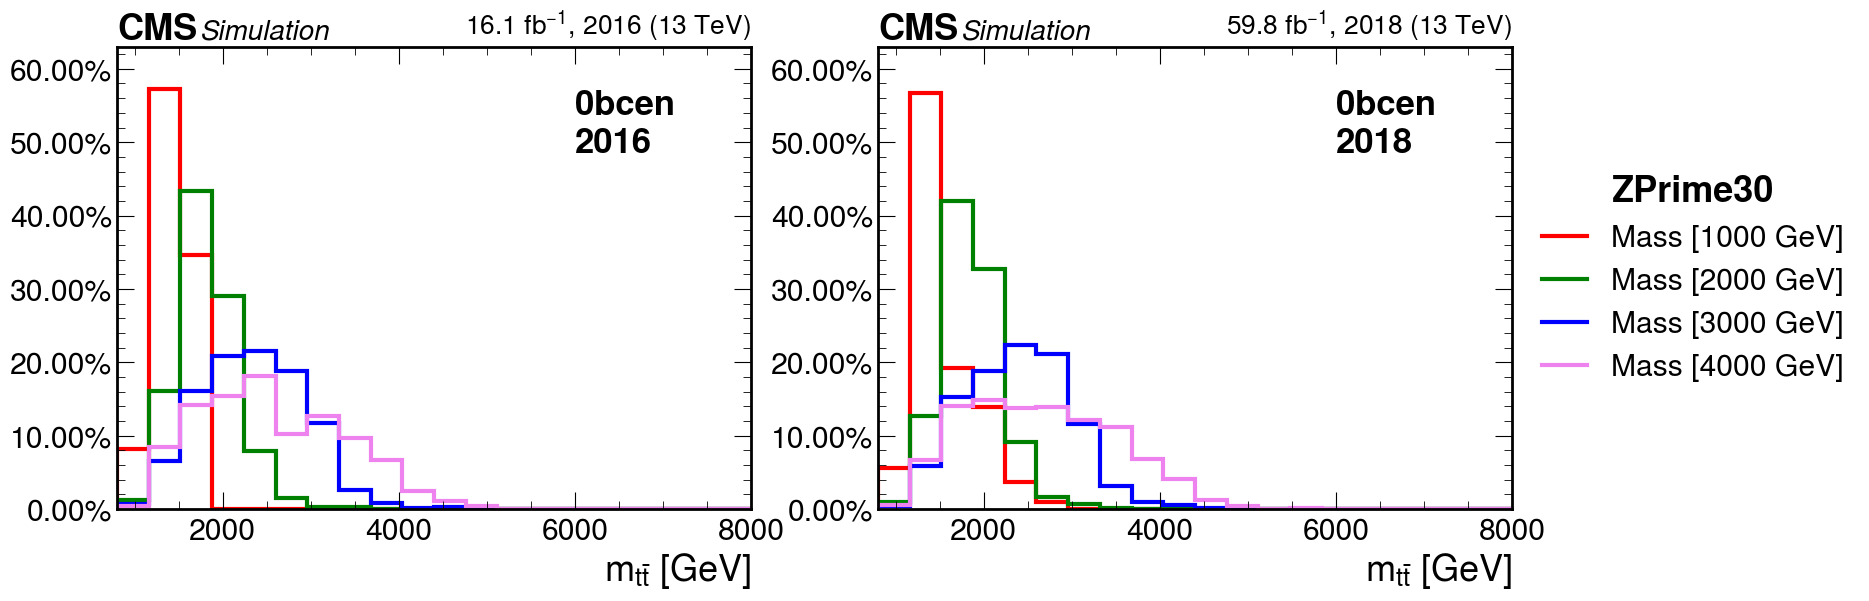

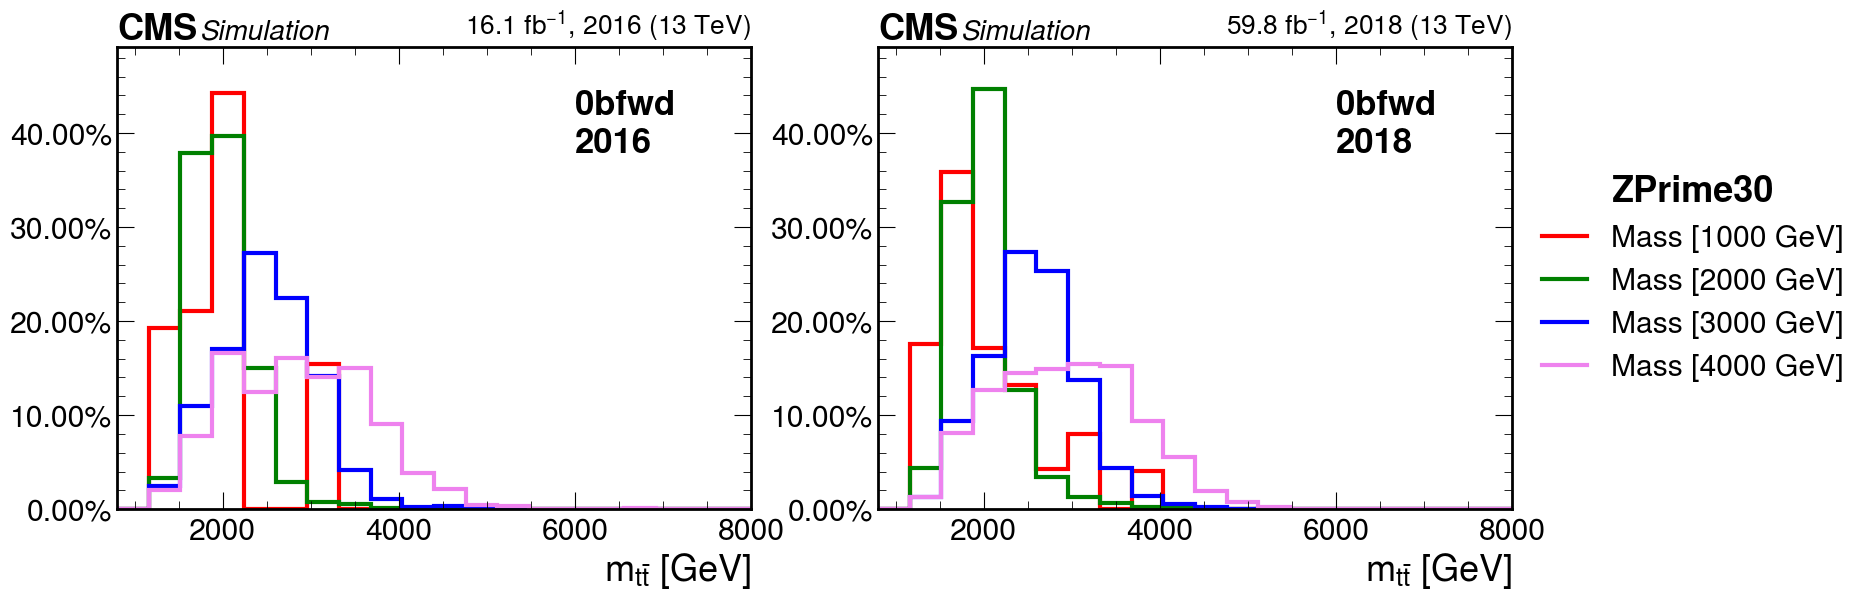

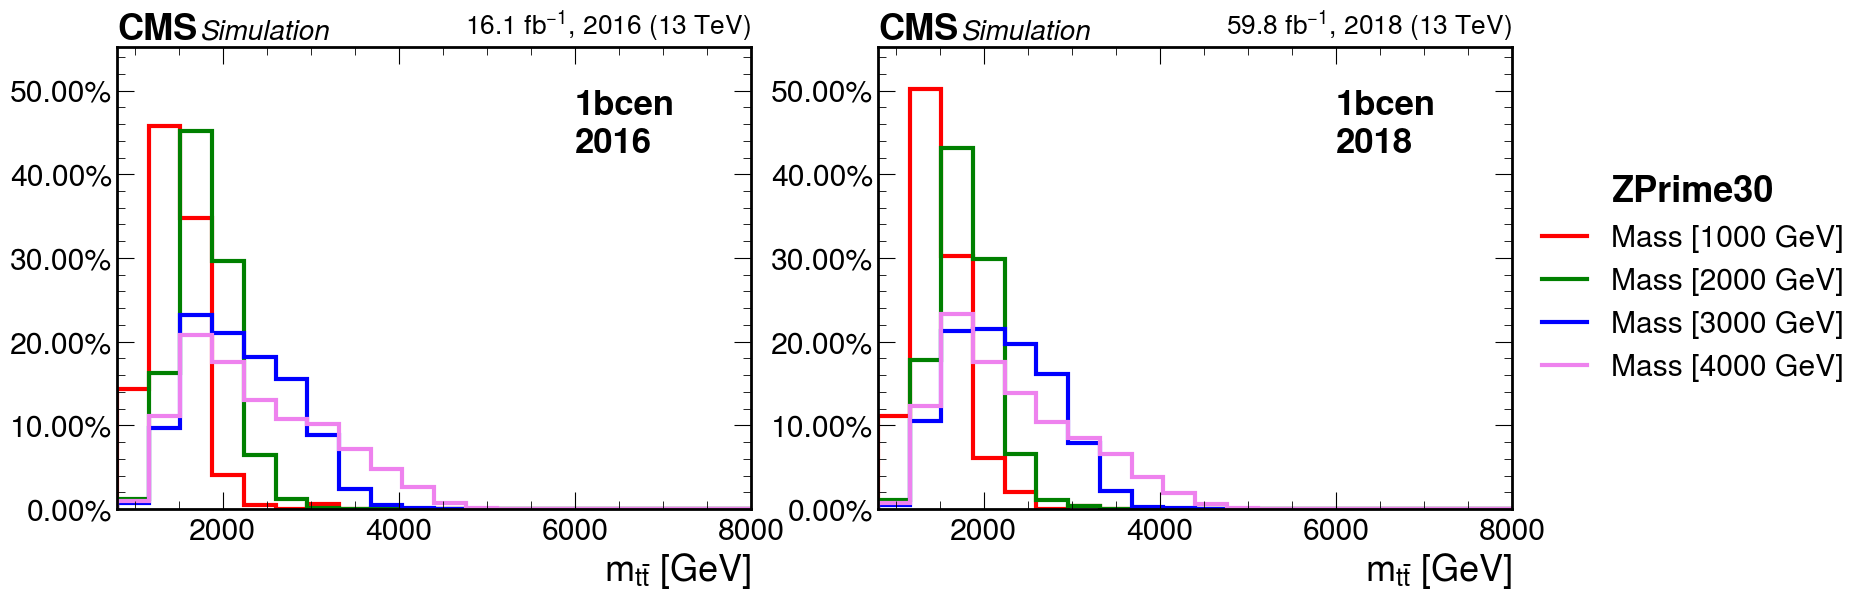

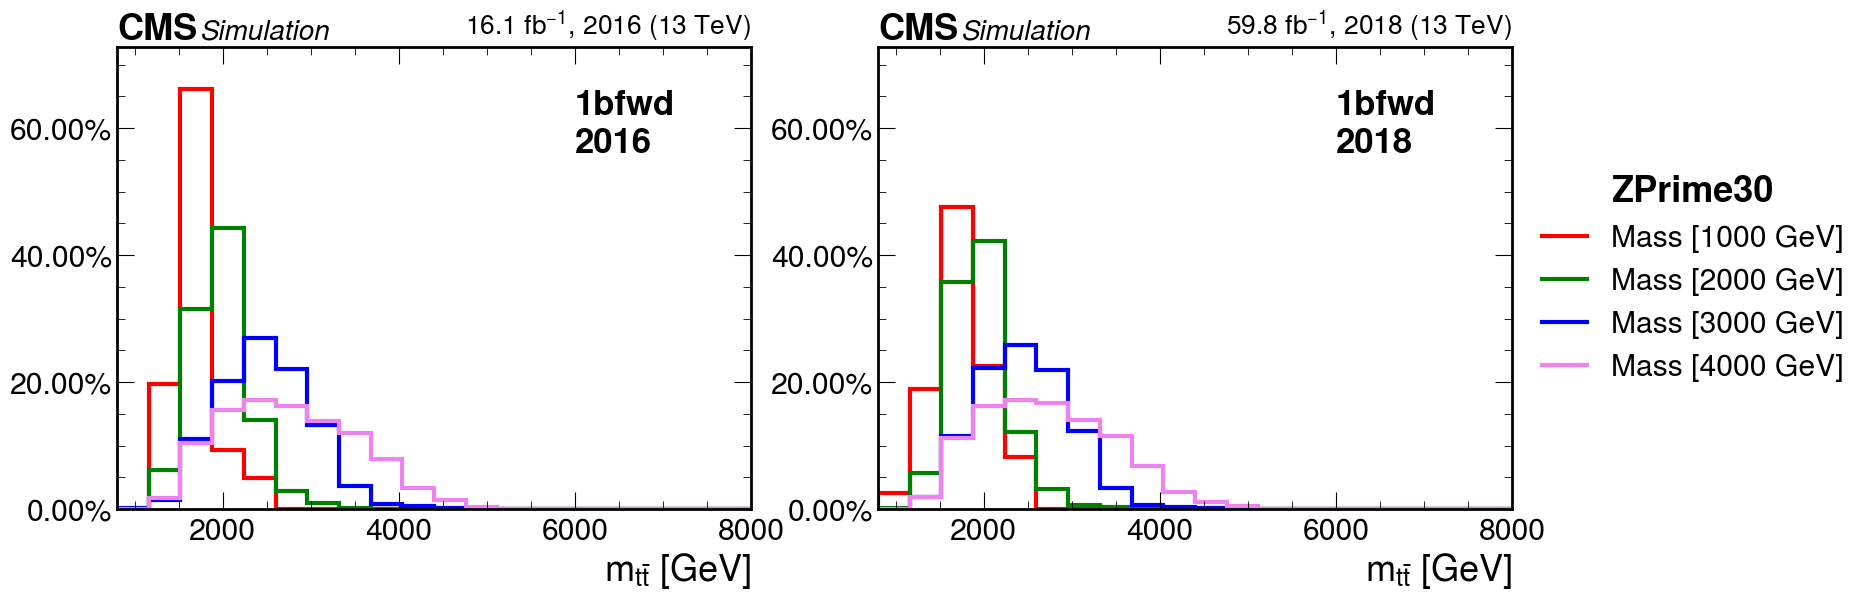

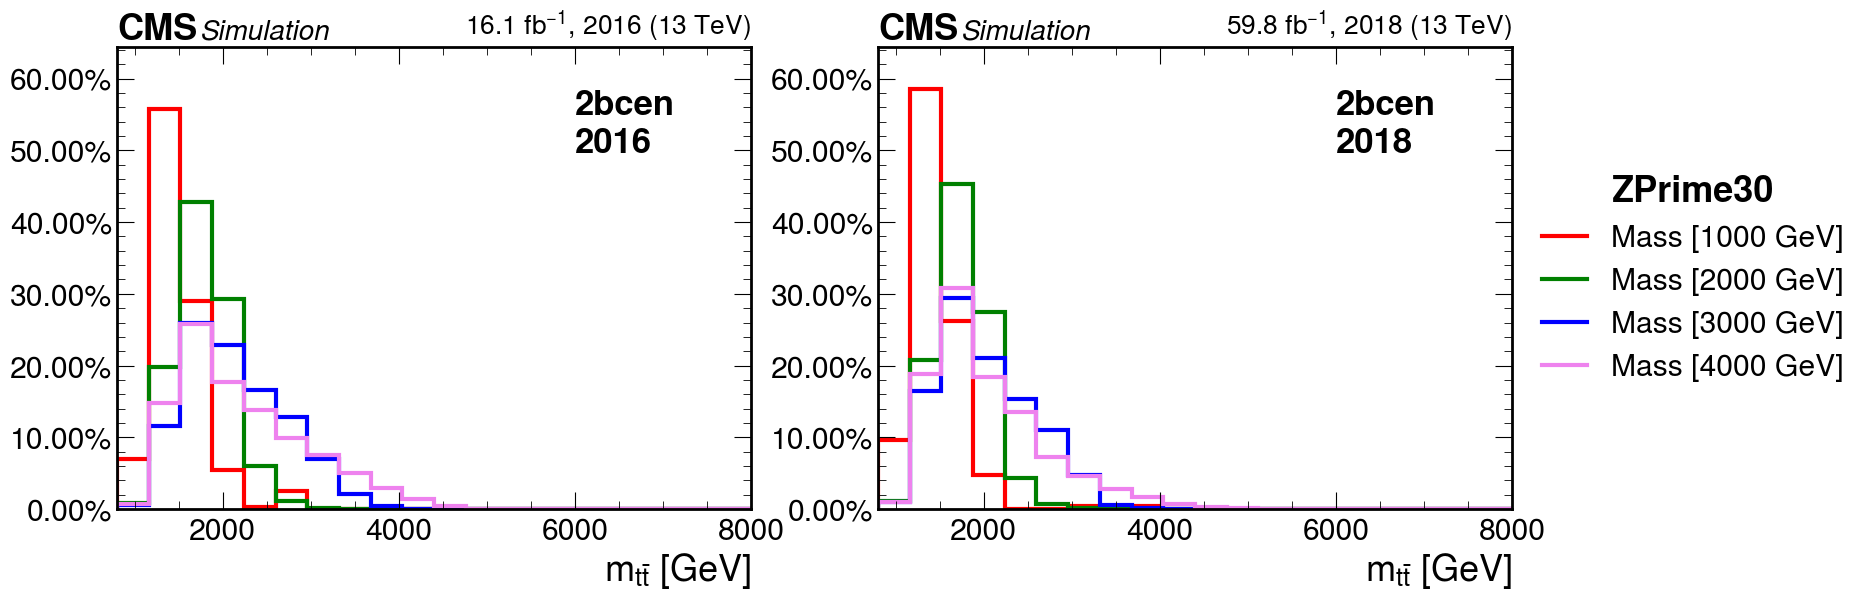

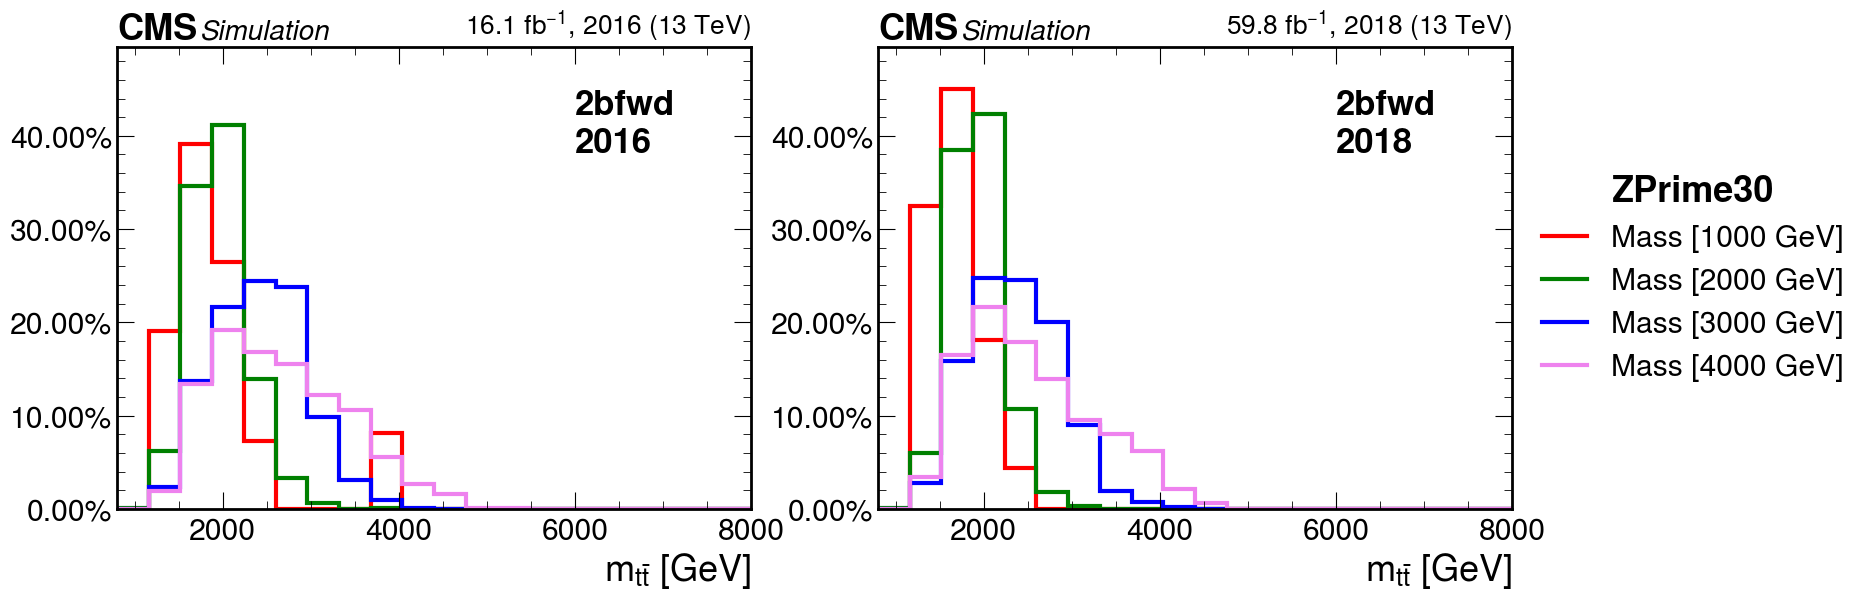

In [45]:
warnings.filterwarnings("ignore")

# Color = ['red', 'pink', 'orange', 'green', 'xkcd:pale gold', 'cyan', 'blue', 'violet', 'grey']
# mass = ['1000', '1200', '1400', '1600', '1800', '2000', '2500', '3000', '3500']

Color = ['red', 'green', 'blue', 'violet']
mass = ['1000', '2000', '3000', '4000']
xaxis = 'ttbarmass'

year1 = '2016'
year2 = '2018'

for cat in categories:
    signal_cats = label_to_int_dict['2t'+cat]
    
    fig, (ax, bx) = plt.subplots(
    ncols = 2,
    figsize=(18,6),
    sharex=True
)
    
    Text = f''
    hep.cms.label('       '+Text, ax=ax, data=False, lumi='{0:0.1f}'.format(lumi[year1]/1000.), year=year1, loc=0, fontsize=20)   
    hep.cms.label('       '+Text, ax=bx, data=False, lumi='{0:0.1f}'.format(lumi[year2]/1000.), year=year2, loc=0, fontsize=20)   
    
    yMax1, yMax2 = [], []
    
    for i in range(4): 
        plothists1 = getHist(xaxis, plotHist, False, year1, [], {'anacat':signal_cats, 'systematic':'nominal'}, mass[i])
        # plothists1 = getHist(xaxis, plotHist, False, year1, [], {'anacat':signal_cats}, mass[i])
        plothists1_norm = plothists1*(1.0/np.sum(plothists1.values()))
        hep.histplot(plothists1_norm, ax=ax, color=Color[i], lw=3, label='Mass ['+mass[i]+' GeV]', yerr=False)
        yMax1.append(np.max(plothists1_norm.values()))
        
        plothists2 = getHist(xaxis, plotHist, False, year2, [], {'anacat':signal_cats, 'systematic':'nominal'}, mass[i])
        # plothists2 = getHist(xaxis, plotHist, False, year2, [], {'anacat':signal_cats}, mass[i])
        plothists2_norm = plothists2*(1.0/np.sum(plothists2.values()))
        hep.histplot(plothists2_norm, ax=bx, color=Color[i], lw=3, label='Mass ['+mass[i]+' GeV]', yerr=False)
        yMax2.append(np.max(plothists2_norm.values()))
        
    # plt.yscale('log')
    
    plt.xlim(800, 8000)
    plt.legend(loc='center left', bbox_to_anchor=(1,0.5), title=plotHist, title_fontproperties={'weight':'bold'})
    
    Y1 = np.max(yMax1)
    Y2 = np.max(yMax2)
    
    ax.set_ylim(0, np.where(Y1>Y2, Y1, Y2)*1.10)
    bx.set_ylim(0, np.where(Y1>Y2, Y1, Y2)*1.10)
    ax.text(6000, np.where(Y1>Y2, Y1, Y2)*0.85, cat+'\n'+year1, fontsize=25, fontweight='bold')
    bx.text(6000, np.where(Y1>Y2, Y1, Y2)*0.85, cat+'\n'+year2, fontsize=25, fontweight='bold')
    
    vals1 = ax.get_yticks()
    ax.set_yticklabels(['{:,.2%}'.format(x) for x in vals1])
    vals2 = bx.get_yticks()
    bx.set_yticklabels(['{:,.2%}'.format(x) for x in vals2])
    # plt.savefig("apv_"+anacats[icat] +".png")
    

[Text(0, 0.0, '0.00%'),
 Text(0, 0.025, '2.50%'),
 Text(0, 0.05, '5.00%'),
 Text(0, 0.07500000000000001, '7.50%'),
 Text(0, 0.1, '10.00%'),
 Text(0, 0.125, '12.50%'),
 Text(0, 0.15000000000000002, '15.00%')]

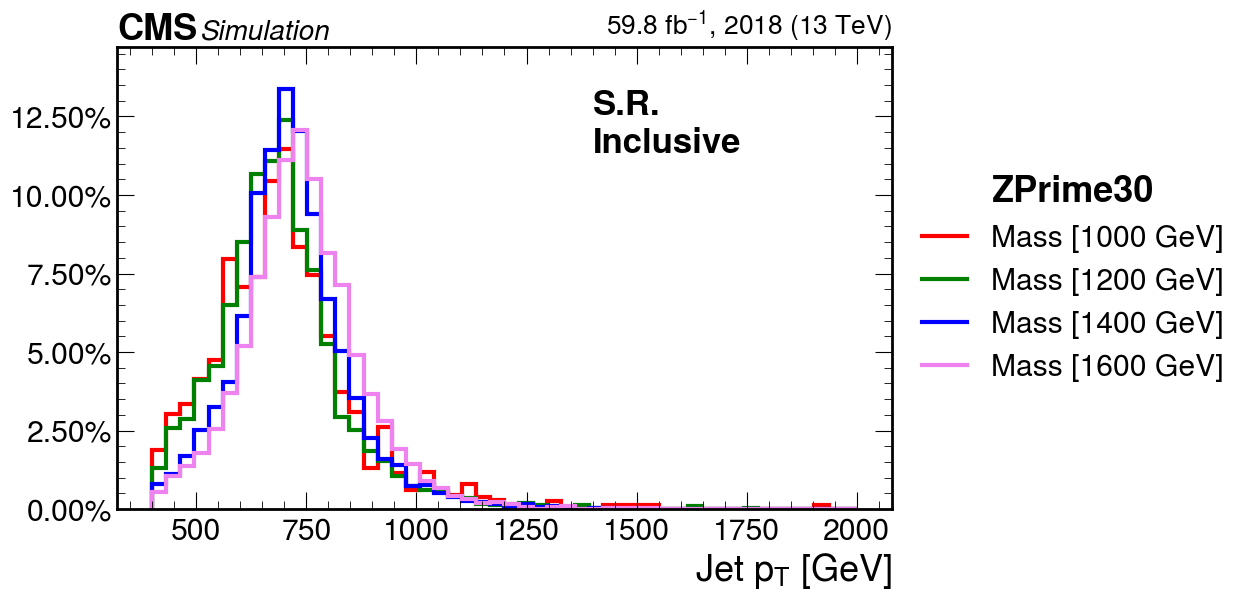

In [46]:
warnings.filterwarnings("ignore")

# Color = ['red', 'pink', 'orange', 'green', 'xkcd:pale gold', 'cyan', 'blue', 'violet', 'grey']
# mass = ['1000', '1200', '1400', '1600', '1800', '2000', '2500', '3000', '3500']

Color = ['red', 'green', 'blue', 'violet']
mass = ['1000', '1200', '1400', '1600']
xaxis = 'jetpt'

year1 = '2018'
# year2 = '2017'

signal_cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]

# fig, (ax, bx) = plt.subplots(
# ncols = 2,
# figsize=(18,6),
# sharex=True
# )

fig, ax = plt.subplots(figsize=(10,6))

Text = f''
hep.cms.label('       '+Text, ax=ax, data=False, lumi='{0:0.1f}'.format(lumi[year1]/1000.), year=year1, loc=0, fontsize=20)   
# hep.cms.label('       '+Text, ax=bx, data=False, lumi='{0:0.1f}'.format(lumi[year2]/1000.), year=year2, loc=0, fontsize=20)   

yMax1 = []
xMax1 = []

for i in range(4): 
    # plothists1 = getHist(xaxis, plotHist, False, year1, ['anacat'], {'anacat':signal_cats, 'systematic':'nominal'}, mass[i])
    plothists1 = getHist(xaxis, plotHist, False, year1, ['anacat'], {'anacat':signal_cats}, mass[i])
    plothists1_norm = plothists1*(1.0/np.sum(plothists1.values()))
    hep.histplot(plothists1_norm, ax=ax, color=Color[i], lw=3, label='Mass ['+mass[i]+' GeV]', yerr=False)
    yMax1.append(np.max(plothists1_norm.values()))
    xMax1.append(np.max(plothists1_norm.axes[xaxis].edges))

# plt.yscale('log')

plt.legend(loc='center left', bbox_to_anchor=(1,0.5), title=plotHist, title_fontproperties={'weight':'bold'})

Y1 = np.max(yMax1)
X1 = np.min(xMax1)
# Y2 = np.max(yMax2)

ax.set_ylim(0, Y1*1.10)
ax.text(X1*0.70, Y1*0.85, 'S.R.\nInclusive', fontsize=25, fontweight='bold')

vals1 = ax.get_yticks()
ax.set_yticklabels(['{:,.2%}'.format(x) for x in vals1])

# plt.savefig("apv_"+anacats[icat] +".png")

(0.717399799036399, 25.728090234361407)

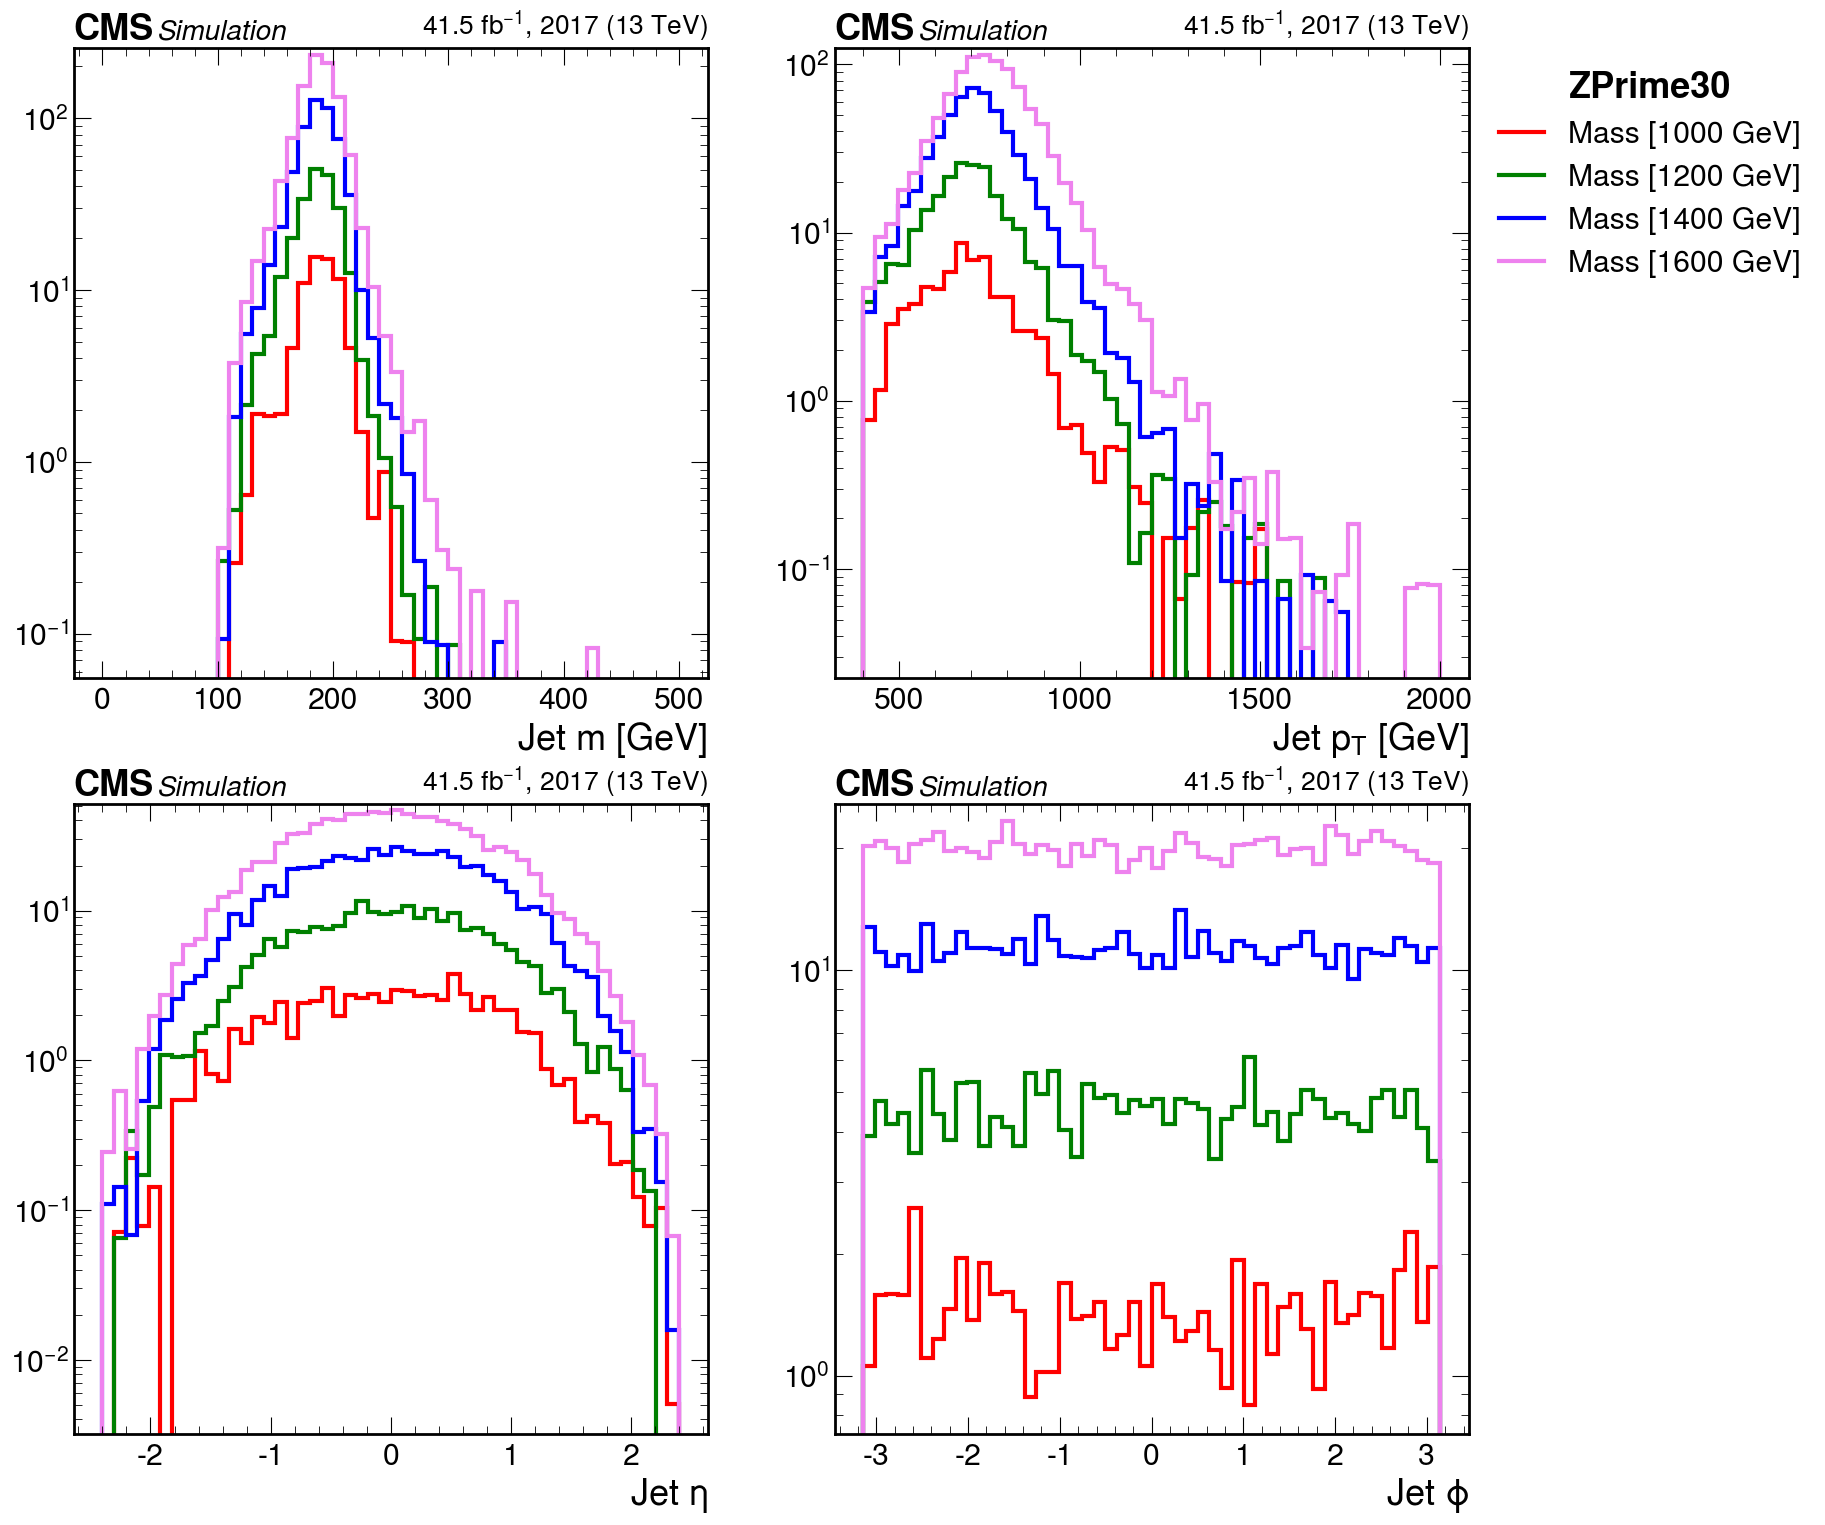

In [48]:
warnings.filterwarnings("ignore")

# Color = ['red', 'pink', 'orange', 'green', 'xkcd:pale gold', 'cyan', 'blue', 'violet', 'grey']
# mass = ['1000', '1200', '1400', '1600', '1800', '2000', '2500', '3000', '3500']

Color = ['red', 'green', 'blue', 'violet']
mass = ['1000', '1200', '1400', '1600']
xaxis1 = 'jetmass'
xaxis2 = 'jetpt'
xaxis3 = 'jeteta'
xaxis4 = 'jetphi'

year1 = '2017'
# year2 = '2017'

signal_cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]

fig, ([ax, bx], [cx, dx]) = plt.subplots(
ncols = 2,
nrows = 2,
figsize=(18,18)
)

# fig, ax = plt.subplots(figsize=(10,6))

Text = f''
hep.cms.label('       '+Text, ax=ax, data=False, lumi='{0:0.1f}'.format(lumi[year1]/1000.), year=year1, loc=0, fontsize=20)   
hep.cms.label('       '+Text, ax=bx, data=False, lumi='{0:0.1f}'.format(lumi[year1]/1000.), year=year1, loc=0, fontsize=20)   
hep.cms.label('       '+Text, ax=cx, data=False, lumi='{0:0.1f}'.format(lumi[year1]/1000.), year=year1, loc=0, fontsize=20)   
hep.cms.label('       '+Text, ax=dx, data=False, lumi='{0:0.1f}'.format(lumi[year1]/1000.), year=year1, loc=0, fontsize=20)   

yMax1, yMax2, yMax3, yMax4 = [], [], [], []
xMax1, xMax2, xMax3, xMax4 = [], [], [], []

for i in range(4): 
    plothists1 = getHist(xaxis1, plotHist, False, year1, ['anacat'], {'anacat':signal_cats}, mass[i])
    plothists1_norm = plothists1*(1.0/np.sum(plothists1.values()))
    hep.histplot(plothists1, ax=ax, color=Color[i], lw=3, label='Mass ['+mass[i]+' GeV]', yerr=False)
    yMax1.append(np.max(plothists1.values()))
    xMax1.append(np.max(plothists1.axes[xaxis1].edges))
    
    plothists2 = getHist(xaxis2, plotHist, False, year1, ['anacat'], {'anacat':signal_cats}, mass[i])
    plothists2_norm = plothists2*(1.0/np.sum(plothists2.values()))
    hep.histplot(plothists2, ax=bx, color=Color[i], lw=3, label='Mass ['+mass[i]+' GeV]', yerr=False)
    yMax2.append(np.max(plothists2.values()))
    xMax2.append(np.max(plothists2.axes[xaxis2].edges))
    
    plothists3 = getHist(xaxis3, plotHist, False, year1, ['anacat'], {'anacat':signal_cats}, mass[i])
    plothists3_norm = plothists3*(1.0/np.sum(plothists3.values()))
    hep.histplot(plothists3, ax=cx, color=Color[i], lw=3, label='Mass ['+mass[i]+' GeV]', yerr=False)
    yMax3.append(np.max(plothists3.values()))
    xMax3.append(np.max(plothists3.axes[xaxis3].edges))
    
    plothists4 = getHist(xaxis4, plotHist, False, year1, ['anacat'], {'anacat':signal_cats}, mass[i])
    plothists4_norm = plothists4*(1.0/np.sum(plothists4.values()))
    hep.histplot(plothists4, ax=dx, color=Color[i], lw=3, label='Mass ['+mass[i]+' GeV]', yerr=False)
    yMax4.append(np.max(plothists4.values()))
    xMax4.append(np.max(plothists4.axes[xaxis4].edges))

ax.set_yscale('log')
bx.set_yscale('log')
cx.set_yscale('log')
dx.set_yscale('log')

plt.legend(loc='center left', bbox_to_anchor=(1,2), title=plotHist, title_fontproperties={'weight':'bold'})

Y1 = np.max(yMax1)
X1 = np.max(xMax1)

Y2 = np.max(yMax2)
X2 = np.max(xMax2)

Y3 = np.max(yMax3)
X3 = np.max(xMax3)

Y4 = np.max(yMax4)
X4 = np.max(xMax4)

ax.set_ylim(0, Y1*1.10)
# ax.text(X1*0.70, Y1*0.85, 'S.R.\nInclusive', fontsize=25, fontweight='bold')
# vals1 = ax.get_yticks()
# ax.set_yticklabels(['{:,.2%}'.format(x) for x in vals1])

bx.set_ylim(0, Y2*1.10)
# bx.text(X2*0.70, Y2*0.85, 'S.R.\nInclusive', fontsize=25, fontweight='bold')
# vals2 = bx.get_yticks()
# bx.set_yticklabels(['{:,.2%}'.format(x) for x in vals2])

cx.set_ylim(0, Y3*1.10)
# cx.text(X3*0.70, Y3*0.85, 'S.R.\nInclusive', fontsize=25, fontweight='bold')
# vals3 = cx.get_yticks()
# cx.set_yticklabels(['{:,.2%}'.format(x) for x in vals3])

dx.set_ylim(0, Y4*1.10)
# dx.text(X4*0.70, Y4*0.85, 'S.R.\nInclusive', fontsize=25, fontweight='bold')
# vals4 = dx.get_yticks()
# dx.set_yticklabels(['{:,.2%}'.format(x) for x in vals4])

# plt.savefig("apv_"+anacats[icat] +".png")